In [8]:
import os
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV

# Thiết lập đường dẫn tới thư mục artifacts (nơi chứa file pkl và csv)
# Nếu file .ipynb nằm cùng thư mục với file script cũ, BASE_DIR sẽ là thư mục cha.
# Bạn có thể điều chỉnh lại đường dẫn cho đúng với cấu trúc thư mục của mình.
BASE_DIR = os.path.dirname(os.getcwd()) # Lấy thư mục cha của thư mục hiện tại
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"📂 Thư mục chứa artifacts: {ARTIFACTS_DIR}")

📂 Thư mục chứa artifacts: d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\artifacts


In [9]:
# 1. Load các tập dữ liệu Train/Test đã chia sẵn
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train_tree.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test_tree.csv'))
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train_tree.csv'))
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test_tree.csv'))

# 2. Load Pipeline tiền xử lý (chỉ chứa bước One-Hot Encoder)
preprocessing_pipeline = joblib.load(os.path.join(ARTIFACTS_DIR, 'tree_preprocessing_pipeline.pkl'))

print("✅ Đã load thành công dữ liệu và pipeline vào Notebook!")
print(f"Kích thước tập X_train gốc: {X_train.shape}")

✅ Đã load thành công dữ liệu và pipeline vào Notebook!
Kích thước tập X_train gốc: (5634, 18)


In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   encoder__Dependents                 5634 non-null   float64
 1   encoder__PaymentMethod              5634 non-null   float64
 2   encoder__InternetService            5634 non-null   float64
 3   encoder__tenure_group               5634 non-null   float64
 4   remainder__SeniorCitizen            5634 non-null   int64  
 5   remainder__Partner                  5634 non-null   int64  
 6   remainder__Tenure                   5634 non-null   int64  
 7   remainder__Contract                 5634 non-null   int64  
 8   remainder__PaperlessBilling         5634 non-null   int64  
 9   remainder__MonthlyCharges           5634 non-null   float64
 10  remainder__TotalCharges             5634 non-null   float64
 11  remainder__OnlineSecurity           5634 no

In [11]:
# 2. Initialize base XGBoost Classifier
xgb_base = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

# Define basic hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("⚙️ Running GridSearchCV optimized for Recall...")
# Scoring is set to 'recall' based on business requirements to minimize False Negatives
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Extract the best model configuration
best_xgb = grid_search.best_estimator_
print(f"🏆 Best Hyperparameters found: {grid_search.best_params_}")

⚙️ Running GridSearchCV optimized for Recall...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
🏆 Best Hyperparameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


c:\Users\HGB\anaconda3\envs\churn_env\lib\site-packages\xgboost\training.py:200: UserWarning: [20:59:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [12]:
# 3. Predict probabilities and default labels
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]
y_pred_default = best_xgb.predict(X_test)

# Evaluation function displaying 5 core classification metrics
def evaluate_model(y_true, y_pred, y_prob, threshold=0.5):
    print(f"--- MODEL PERFORMANCE METRICS (Threshold = {threshold:.4f}) ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}\n")

evaluate_model(y_test, y_pred_default, y_pred_proba, threshold=0.5)

--- MODEL PERFORMANCE METRICS (Threshold = 0.5000) ---
Accuracy  : 0.8020
Precision : 0.6471
Recall    : 0.5588
F1-Score  : 0.5997
ROC-AUC   : 0.8562



In [13]:
# 4. Analyze Precision-Recall Curve to adjust classification threshold
print("🔍 Analyzing Precision-Recall Curve to optimize threshold for Recall...")
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Define target recall strategy (e.g., catching at least 85% of churned customers)
target_recall = 0.85
optimal_idx = np.where(recalls >= target_recall)[0][-1]
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]

print(f"💡 Suggested threshold to maximize Recall (~{target_recall}): {optimal_threshold:.4f}")

# Re-evaluate model predictions with the custom threshold
y_pred_adjusted = (y_pred_proba >= optimal_threshold).astype(int)
evaluate_model(y_test, y_pred_adjusted, y_pred_proba, threshold=optimal_threshold)

🔍 Analyzing Precision-Recall Curve to optimize threshold for Recall...
💡 Suggested threshold to maximize Recall (~0.85): 0.2213
--- MODEL PERFORMANCE METRICS (Threshold = 0.2213) ---
Accuracy  : 0.7289
Precision : 0.4938
Recall    : 0.8503
F1-Score  : 0.6248
ROC-AUC   : 0.8562



Số lượng Feature names: 18
Số lượng Importances: 18


C:\Users\HGB\AppData\Local\Temp\ipykernel_20520\1309659838.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Đã lưu biểu đồ thành công tại: xgboost_feature_importance.png



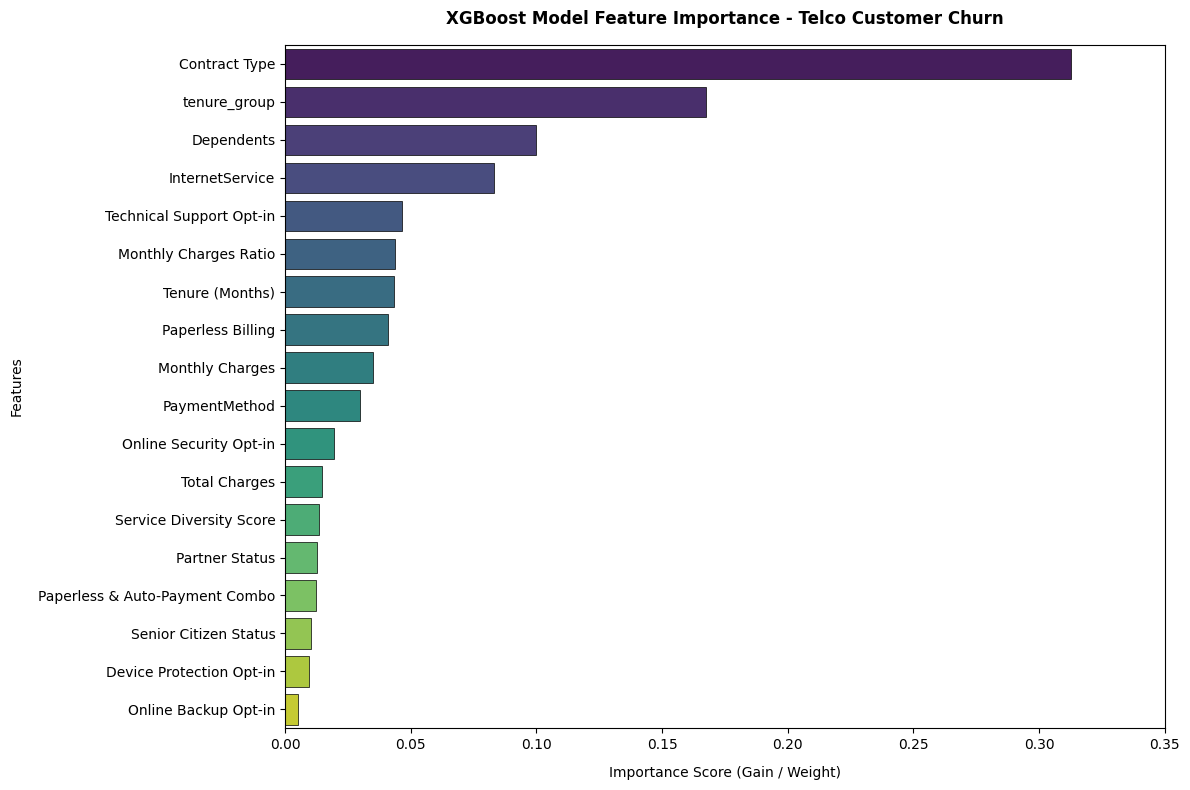

📌 Top 5 Most Influential Features Driving Customer Churn:
-----------------------------------------------------------------
                 Feature  Importance (%)
           Contract Type           31.28
            tenure_group           16.73
              Dependents           10.00
         InternetService            8.31
Technical Support Opt-in            4.64
-----------------------------------------------------------------


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract, clean, and visualize Feature Importance
feature_names = best_xgb.feature_names_in_ 
importances = best_xgb.feature_importances_

# In ra để kiểm tra chắc chắn độ dài đã khớp
print(f"Số lượng Feature names: {len(feature_names)}")
print(f"Số lượng Importances: {len(importances)}")

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Dùng Regex để xóa triệt để tiền tố 'encoder__' hoặc 'remainder__' và xóa khoảng trắng thừa
importance_df['Feature'] = (
    importance_df['Feature']
    .str.replace(r'^(encoder__|remainder__)', '', regex=True)
    .str.strip()
)

# 2. Bảng từ điển map TOÀN BỘ 25 cột
custom_names = {
    # Nhóm biến sinh ra từ One-Hot Encoding
    'Dependents_Yes': 'Dependents: Yes',
    'PaymentMethod_Credit card (automatic)': 'Payment Method: Credit Card (Auto)',
    'PaymentMethod_Electronic check': 'Payment Method: Electronic Check',
    'PaymentMethod_Mailed check': 'Payment Method: Mailed Check',
    'InternetService_Fiber optic': 'Internet Service: Fiber Optic',
    'InternetService_No': 'Internet Service: None',
    'tenure_group_13-24 months': 'Tenure Group: 13-24 Months',
    'tenure_group_25-36 months': 'Tenure Group: 25-36 Months',
    'tenure_group_37-48 months': 'Tenure Group: 37-48 Months',
    'tenure_group_49-60 months': 'Tenure Group: 49-60 Months',
    'tenure_group_61-72 months': 'Tenure Group: 61-72 Months',
    
    # Nhóm biến số / Nhị phân giữ nguyên (Remainder)
    'SeniorCitizen': 'Senior Citizen Status',
    'Partner': 'Partner Status',
    'Tenure': 'Tenure (Months)',
    'Contract': 'Contract Type',
    'PaperlessBilling': 'Paperless Billing',
    'MonthlyCharges': 'Monthly Charges',
    'TotalCharges': 'Total Charges',
    'OnlineSecurity': 'Online Security Opt-in',
    'OnlineBackup': 'Online Backup Opt-in',
    'DeviceProtection': 'Device Protection Opt-in',
    'TechSupport': 'Technical Support Opt-in',
    
    # Nhóm Feature Engineering
    'service_diversity': 'Service Diversity Score',
    'monthly_charges_ratio': 'Monthly Charges Ratio',
    'is_paperless_electronic': 'Paperless & Auto-Payment Combo'
}

# ==========================================
# 3. ÁP DỤNG MAPPING (ĐÃ SỬA LỖI)
# ==========================================
# Thay 'coef_df' thành 'importance_df' và ghi đè thẳng lên cột 'Feature'
importance_df['Feature'] = importance_df['Feature'].map(custom_names).fillna(importance_df['Feature'])

# Sắp xếp giá trị Importance giảm dần
importance_df = importance_df.sort_values(by='Importance', ascending=False)


# ==========================================
# 4. VẼ BIỂU ĐỒ FEATURE IMPORTANCE
# ==========================================
plt.figure(figsize=(12, 8))

# Vẽ Barplot ngang, thêm viền đen mảnh cho sắc nét
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='viridis',
    edgecolor='black',
    linewidth=0.5
)

# Cấu hình Tiêu đề và Nhãn chuẩn học thuật
plt.title('XGBoost Model Feature Importance - Telco Customer Churn', fontweight='bold', pad=15)
plt.xlabel('Importance Score (Gain / Weight)', labelpad=10)
plt.ylabel('Features', labelpad=10)

# Cấu hình chia vạch trục X (nếu dữ liệu thực tế vượt quá 0.40, bạn có thể comment lại dòng này)
plt.xticks(np.arange(0, 0.40, 0.05))

# Tối ưu layout
plt.tight_layout()

# Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
save_path = 'xgboost_feature_importance.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Đã lưu biểu đồ thành công tại: {save_path}\n")

plt.show()


# ==========================================
# 5. IN KẾT QUẢ RA CONSOLE
# ==========================================
# Bổ sung cột phần trăm
importance_df["Importance (%)"] = (importance_df["Importance"] * 100).round(2)

print("📌 Top 5 Most Influential Features Driving Customer Churn:")
print("-" * 65)

cols_to_print = ["Feature", "Importance (%)"]

# In ra giới hạn 5 cột đầu tiên
print(
    importance_df[cols_to_print]
    .head(5)
    .to_string(
        index=False, 
        float_format=lambda x: f"{x:.2f}"
    )
)
print("-" * 65)